# Precious-Metals Statistical Arbitrage

## 1. Research question and decision standard

This notebook asks whether economically related precious-metals instruments exhibit a repeatable divergence/convergence effect that remains tradable after costs. It may conclude that no useful statistical arbitrage exists. Statistical significance is necessary, not sufficient, and none of the results guarantees future profit.

Verdicts are restricted to **Robust statistical-arbitrage evidence**, **Interesting but weak evidence**, or **No useful statistical arbitrage**.

## 2. Imports, deterministic configuration, and assumptions

Every historical estimate is point-in-time. The signal is observed first, execution occurs one session later, and P&L starts after execution. The base model charges 5 basis points per dollar of one-way turnover and 2% annualized short borrow.

The workflow follows the practical cautions in Michael Isichenko, *Quantitative Portfolio Management* (Wiley, 2021): prefer economically motivated relationships to brute-force pair mining, translate residual forecasts into actual tradable legs, model point-in-time information and costs, and avoid repeated P&L-driven tuning.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, replace
from typing import Any, Callable
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.stattools import adfuller, coint

from ats.ticker import EquityTicker

RANDOM_SEED = 20260926
TRADABLE_TICKERS = ("GLD", "IAU", "SLV", "GDX", "GDXJ", "SIL", "SILJ")
FACTOR_TICKERS = ("SPY", "UUP", "IEF", "TIP")


@dataclass(frozen=True)
class ResearchConfig:
    discovery_fraction: float = 0.60
    validation_fraction: float = 0.20
    entry_z: float = 2.0
    exit_z: float = 0.5
    max_holding_days: int = 20
    transaction_cost_bps: float = 5.0
    annual_short_borrow: float = 0.02
    bootstrap_repetitions: int = 2_000
    bootstrap_block_length: int = 40
    horizons: tuple[int, ...] = (1, 5, 10, 20, 40)
    estimation_windows: tuple[int, ...] = (252, 504)
    accumulation_windows: tuple[int, ...] = (5, 10, 20)
    normalization_windows: tuple[int, ...] = (126, 252)
    robustness_entry_z: tuple[float, ...] = (1.5, 2.0, 2.5)
    robustness_exit_z: tuple[float, ...] = (0.0, 0.5)
    robustness_holding_days: tuple[int, ...] = (10, 20, 40)
    robustness_cost_bps: tuple[float, ...] = (2.0, 5.0, 10.0)
    robustness_borrow: tuple[float, ...] = (0.0, 0.02, 0.05)


@dataclass(frozen=True)
class SplitBoundaries:
    discovery_end: pd.Timestamp
    validation_end: pd.Timestamp
    test_end: pd.Timestamp


CONFIG = ResearchConfig()
np.random.seed(RANDOM_SEED)


def validate_price_panel(prices: pd.DataFrame) -> pd.DataFrame:
    '''Return sorted positive finite prices without inventing observations.'''
    if prices.index.has_duplicates:
        duplicates = prices.index[prices.index.duplicated()].unique()
        raise ValueError(f"duplicate price dates: {duplicates.tolist()}")
    clean = prices.copy()
    clean.index = pd.DatetimeIndex(clean.index)
    clean = clean.sort_index().astype(float)
    return clean.where(np.isfinite(clean) & clean.gt(0.0))


def simple_and_log_returns(prices: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    '''Compute close-to-close returns while preserving gaps as missing.'''
    clean = validate_price_panel(prices)
    observed_pair = clean.notna() & clean.shift(1).notna()
    simple = clean.pct_change(fill_method=None).where(observed_pair)
    log = np.log(clean).diff().where(observed_pair)
    return simple, log


def fetch_price_panel(
    tickers: tuple[str, ...],
    ticker_factory: Callable[..., EquityTicker] = EquityTicker,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    '''Fetch maximum ATS histories and return a wide panel plus an audit table.'''
    series: dict[str, pd.Series] = {}
    audit_rows: list[dict[str, Any]] = []
    for symbol in tickers:
        try:
            ticker = ticker_factory(symbol).fetch_price_data(
                all_available_price_history=True
            )
            frame = ticker.price_data.select("date", "close").to_pandas()
            frame["date"] = pd.to_datetime(frame["date"])
            if frame.empty:
                raise ValueError("empty download")
            if frame["date"].duplicated().any():
                raise ValueError("duplicate dates")
            values = pd.Series(
                frame["close"].to_numpy(dtype=float),
                index=pd.DatetimeIndex(frame["date"]),
                name=symbol,
            ).sort_index()
            values = values.where(np.isfinite(values) & values.gt(0.0))
            series[symbol] = values
            audit_rows.append(
                {
                    "symbol": symbol,
                    "status": "ok",
                    "first_date": values.first_valid_index(),
                    "last_date": values.last_valid_index(),
                    "observations": int(values.notna().sum()),
                    "missing": int(values.isna().sum()),
                }
            )
        except Exception as exc:
            audit_rows.append(
                {
                    "symbol": symbol,
                    "status": f"excluded: {exc}",
                    "first_date": pd.NaT,
                    "last_date": pd.NaT,
                    "observations": 0,
                    "missing": 0,
                }
            )
    panel = (
        pd.concat(series.values(), axis=1, sort=True).sort_index()
        if series
        else pd.DataFrame()
    )
    return panel, pd.DataFrame(audit_rows).set_index("symbol")


def chronological_boundaries(index: pd.DatetimeIndex) -> SplitBoundaries:
    '''Create ordered 60/20/20 date boundaries once for a candidate sample.'''
    dates = pd.DatetimeIndex(index).drop_duplicates().sort_values()
    if len(dates) < 5:
        raise ValueError("at least five observations are required for chronological splits")
    discovery_count = max(1, int(np.floor(len(dates) * CONFIG.discovery_fraction)))
    validation_count = max(1, int(np.floor(len(dates) * CONFIG.validation_fraction)))
    validation_end_pos = min(discovery_count + validation_count - 1, len(dates) - 2)
    return SplitBoundaries(
        discovery_end=dates[discovery_count - 1],
        validation_end=dates[validation_end_pos],
        test_end=dates[-1],
    )


def rolling_ols_lagged(
    y: pd.Series,
    x: pd.DataFrame,
    window: int,
    ridge_alpha: float = 0.0,
) -> tuple[pd.DataFrame, pd.Series]:
    '''Fit trailing regressions through t-1 and stamp coefficients/residual at t.'''
    if window < 2:
        raise ValueError("window must be at least two")
    aligned = pd.concat([y.rename("__target__"), x], axis=1).sort_index()
    columns = ["const", *x.columns]
    coefficients = pd.DataFrame(np.nan, index=aligned.index, columns=columns)
    residuals = pd.Series(np.nan, index=aligned.index, name="residual")
    penalty = np.diag([0.0, *([1.0] * x.shape[1])])

    for position in range(window, len(aligned)):
        history = aligned.iloc[position - window : position].dropna()
        if len(history) <= len(columns):
            continue
        design = np.column_stack(
            [np.ones(len(history)), history[x.columns].to_numpy(dtype=float)]
        )
        target = history["__target__"].to_numpy(dtype=float)
        condition = np.linalg.cond(design)
        if ridge_alpha > 0.0:
            estimate = np.linalg.solve(
                design.T @ design + ridge_alpha * penalty,
                design.T @ target,
            )
        elif not np.isfinite(condition) or condition > 1e12:
            continue
        else:
            estimate = np.linalg.lstsq(design, target, rcond=None)[0]
        timestamp = aligned.index[position]
        coefficients.loc[timestamp] = estimate
        current = aligned.iloc[position]
        if current.notna().all():
            current_design = np.r_[1.0, current[x.columns].to_numpy(dtype=float)]
            residuals.loc[timestamp] = float(current["__target__"] - current_design @ estimate)
    return coefficients, residuals


def lagged_robust_zscore(values: pd.Series, window: int) -> pd.Series:
    '''Standardize each value from a median and scale ending at t-1.'''
    if window < 3:
        raise ValueError("window must be at least three")
    result = pd.Series(np.nan, index=values.index, name="zscore")
    numeric = values.astype(float)
    for position in range(window, len(numeric)):
        history = numeric.iloc[position - window : position].dropna()
        current = numeric.iloc[position]
        if len(history) < max(3, window // 2) or not np.isfinite(current):
            continue
        center = float(history.median())
        mad = float((history - center).abs().median())
        scale = 1.4826 * mad
        if not np.isfinite(scale) or scale <= 0.0:
            scale = float(history.std(ddof=1))
        if np.isfinite(scale) and scale > 0.0:
            result.iloc[position] = (current - center) / scale
    return result


@dataclass(frozen=True)
class Candidate:
    name: str
    family: str
    spread: pd.Series
    zscore: pd.Series
    leg_weights: pd.DataFrame
    diagnostics: dict[str, Any]


def _normalize_rows(weights: pd.DataFrame) -> pd.DataFrame:
    gross = weights.abs().sum(axis=1).replace(0.0, np.nan)
    return weights.div(gross, axis=0)


def make_cointegration_candidate(
    log_prices: pd.DataFrame,
    left: str,
    right: str,
    estimation_window: int,
    normalization_window: int,
    discovery_mask: pd.Series,
) -> Candidate | None:
    '''Build a lagged rolling Engle-Granger spread for an economic pair.'''
    data = log_prices[[left, right]].dropna().sort_index()
    if len(data) < estimation_window + normalization_window + 20:
        return None
    mask = discovery_mask.reindex(data.index).fillna(False).astype(bool)
    discovery = data.loc[mask]
    if len(discovery) < estimation_window + 20:
        return None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        _, coint_pvalue, _ = coint(discovery[left], discovery[right])
    coefficients, residual = rolling_ols_lagged(
        data[left], data[[right]], estimation_window
    )
    beta = coefficients[right]
    weights = _normalize_rows(pd.DataFrame({left: 1.0, right: -beta}, index=data.index))
    zscore = lagged_robust_zscore(residual, normalization_window)
    beta_discovery = beta.loc[mask].dropna()
    beta_scale = abs(float(beta_discovery.mean()))
    stability = float(beta_discovery.std() / beta_scale) if beta_scale > 1e-12 else np.inf
    return Candidate(
        name=f"coint:{left}~{right}:w{estimation_window}:z{normalization_window}",
        family="cointegration",
        spread=residual.rename("spread"),
        zscore=zscore,
        leg_weights=weights,
        diagnostics={
            "coint_pvalue": float(coint_pvalue),
            "stationarity_ok": bool(np.isfinite(coint_pvalue) and coint_pvalue < 0.05),
            "stable_weights": bool(np.isfinite(stability) and stability < 0.75),
            "weight_variation": stability,
            "coefficients": coefficients,
            "definition": f"log({left}) - alpha[t-1] - beta[t-1] log({right})",
        },
    )


def make_factor_candidate(
    log_returns: pd.DataFrame,
    target: str,
    factors: tuple[str, ...],
    estimation_window: int,
    accumulation_window: int,
    normalization_window: int,
    discovery_mask: pd.Series,
    ridge_alpha: float = 0.0,
) -> Candidate | None:
    '''Build a trailing factor-residual displacement with tradable hedge legs.'''
    columns = [target, *factors]
    data = log_returns[columns].dropna().sort_index()
    if len(data) < estimation_window + normalization_window + accumulation_window:
        return None
    coefficients, residual = rolling_ols_lagged(
        data[target], data[list(factors)], estimation_window, ridge_alpha
    )
    displacement = residual.rolling(accumulation_window, min_periods=accumulation_window).sum()
    zscore = lagged_robust_zscore(displacement, normalization_window)
    raw_weights = pd.DataFrame(index=data.index, columns=columns, dtype=float)
    raw_weights[target] = 1.0
    for factor in factors:
        raw_weights[factor] = -coefficients[factor]
    weights = _normalize_rows(raw_weights)
    mask = discovery_mask.reindex(data.index).fillna(False).astype(bool)
    coefficient_slice = coefficients.loc[mask, list(factors)].dropna()
    variation = float(coefficient_slice.std().mean()) if not coefficient_slice.empty else np.inf
    discovery_residual = residual.loc[mask].dropna()
    stationarity_pvalue = (
        float(adfuller(discovery_residual, autolag="AIC")[1])
        if len(discovery_residual) >= 50
        else np.nan
    )
    return Candidate(
        name=(
            f"factor:{target}~{'+'.join(factors)}:w{estimation_window}:"
            f"k{accumulation_window}:z{normalization_window}"
        ),
        family="factor_residual",
        spread=displacement.rename("spread"),
        zscore=zscore,
        leg_weights=weights,
        diagnostics={
            "stationarity_pvalue": stationarity_pvalue,
            "stationarity_ok": bool(
                np.isfinite(stationarity_pvalue) and stationarity_pvalue < 0.05
            ),
            "stable_weights": bool(np.isfinite(variation) and variation < 0.75),
            "weight_variation": variation,
            "coefficients": coefficients,
            "residual_return": residual,
            "definition": (
                f"{accumulation_window}-day sum of lagged-OLS {target} residuals "
                f"against {', '.join(factors)}"
            ),
        },
    )


def make_pca_candidates(
    log_returns: pd.DataFrame,
    assets: tuple[str, ...],
    estimation_window: int,
    accumulation_window: int,
    normalization_window: int,
    discovery_mask: pd.Series,
) -> list[Candidate]:
    '''Build rolling PCA reconstruction-residual candidates for a coherent basket.'''
    data = log_returns[list(assets)].dropna().sort_index()
    if len(data) < estimation_window + normalization_window + accumulation_window:
        return []
    residuals = pd.DataFrame(np.nan, index=data.index, columns=assets)
    weight_panels = {
        asset: pd.DataFrame(np.nan, index=data.index, columns=assets) for asset in assets
    }
    explained = pd.Series(np.nan, index=data.index)
    component_count = pd.Series(np.nan, index=data.index)
    for position in range(estimation_window, len(data)):
        history = data.iloc[position - estimation_window : position]
        means = history.mean()
        scales = history.std(ddof=1)
        if (scales <= 0.0).any() or not np.isfinite(scales).all():
            continue
        standardized = (history - means) / scales
        covariance = standardized.cov().to_numpy()
        eigenvalues, eigenvectors = np.linalg.eigh(covariance)
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]
        ratios = eigenvalues / eigenvalues.sum()
        components = min(2, int(np.searchsorted(np.cumsum(ratios), 0.70) + 1))
        loadings = eigenvectors[:, :components]
        projection = loadings @ loadings.T
        residual_operator = np.eye(len(assets)) - projection
        current = ((data.iloc[position] - means) / scales).to_numpy(dtype=float)
        current_residual = residual_operator @ current
        timestamp = data.index[position]
        residuals.loc[timestamp] = current_residual
        explained.loc[timestamp] = float(ratios[:components].sum())
        component_count.loc[timestamp] = components
        return_operator = residual_operator @ np.diag(1.0 / scales.to_numpy())
        for asset_position, asset in enumerate(assets):
            weight_panels[asset].loc[timestamp] = return_operator[asset_position]

    candidates: list[Candidate] = []
    mask = discovery_mask.reindex(data.index).fillna(False).astype(bool)
    for asset in assets:
        displacement = residuals[asset].rolling(
            accumulation_window, min_periods=accumulation_window
        ).sum()
        zscore = lagged_robust_zscore(displacement, normalization_window)
        weights = _normalize_rows(weight_panels[asset])
        discovered = displacement.loc[mask].dropna()
        stationarity_pvalue = (
            float(adfuller(discovered, autolag="AIC")[1]) if len(discovered) >= 50 else np.nan
        )
        candidates.append(
            Candidate(
                name=(
                    f"pca:{asset}|{'+'.join(assets)}:w{estimation_window}:"
                    f"k{accumulation_window}:z{normalization_window}"
                ),
                family="pca_residual",
                spread=displacement.rename("spread"),
                zscore=zscore,
                leg_weights=weights,
                diagnostics={
                    "stationarity_pvalue": stationarity_pvalue,
                    "stationarity_ok": bool(
                        np.isfinite(stationarity_pvalue) and stationarity_pvalue < 0.05
                    ),
                    "stable_weights": True,
                    "explained_variance": explained,
                    "component_count": component_count,
                    "residual_return": residuals[asset],
                    "definition": (
                        f"{accumulation_window}-day rolling-PCA reconstruction residual "
                        f"for {asset} in {', '.join(assets)}"
                    ),
                },
            )
        )
    return candidates

## 3. ATS API audit and data acquisition

Data are fetched below through `EquityTicker`; adjusted closes and actual observation dates are retained.

In [2]:
from IPython.display import Markdown, display

ALL_TICKERS = tuple(dict.fromkeys((*TRADABLE_TICKERS, *FACTOR_TICKERS)))
prices, data_audit = fetch_price_panel(ALL_TICKERS)
display(data_audit)
print(f"Data cutoff: {prices.index.max().date() if not prices.empty else 'no data'}")
print(f"Fetched {prices.shape[1]} of {len(ALL_TICKERS)} requested instruments.")

,status,first_date,last_date,observations,missing
symbol,,,,,
GLD,ok,2004-11-18,2026-09-25,5497,0
IAU,ok,2005-01-28,2026-09-25,5449,0
SLV,ok,2006-04-28,2026-09-25,5135,0
GDX,ok,2006-05-22,2026-09-25,5119,0
GDXJ,ok,2009-11-11,2026-09-25,4243,0
SIL,ok,2010-04-20,2026-09-25,4135,0
SILJ,ok,2012-11-29,2026-09-25,3476,0
SPY,ok,1993-01-29,2026-09-25,8472,0
UUP,ok,2007-03-01,2026-09-25,4925,0


Data cutoff: 2026-09-25
Fetched 11 of 11 requested instruments.


## 4. Data quality and chronological splits

Each candidate uses chronological 60/20/20 discovery, validation, and untouched-test partitions.

In [3]:
CORE_COLUMNS = ("GLD", "GDX", "SPY", "UUP")
missing_core = [symbol for symbol in CORE_COLUMNS if symbol not in prices]
RESEARCH_READY = not missing_core
if RESEARCH_READY:
    common_core = prices[list(CORE_COLUMNS)].dropna()
    RESEARCH_READY = len(common_core) >= 5 * 252
if RESEARCH_READY:
    boundaries = chronological_boundaries(common_core.index)
    study_start = common_core.index.min()
    analysis_prices = validate_price_panel(prices.loc[study_start:])
    simple_returns, log_returns = simple_and_log_returns(analysis_prices)
    log_prices = np.log(analysis_prices)
    discovery_mask = pd.Series(
        analysis_prices.index <= boundaries.discovery_end,
        index=analysis_prices.index,
    )
    split_table = pd.DataFrame(
        {
            "split": ["discovery", "validation", "test"],
            "start": [analysis_prices.index.min(), boundaries.discovery_end, boundaries.validation_end],
            "end": [boundaries.discovery_end, boundaries.validation_end, boundaries.test_end],
        }
    )
    display(split_table)
    assert boundaries.discovery_end < boundaries.validation_end < boundaries.test_end
else:
    boundaries = None
    analysis_prices = pd.DataFrame()
    simple_returns = pd.DataFrame()
    log_returns = pd.DataFrame()
    log_prices = pd.DataFrame()
    discovery_mask = pd.Series(dtype=bool)
    print(
        "Research cannot run: "
        + (f"missing core instruments {missing_core}" if missing_core else "fewer than five years of common core data")
    )

,split,start,end
0,discovery,2007-03-01,2018-11-20
1,validation,2018-11-20,2022-10-20
2,test,2022-10-20,2026-09-25


## 5. Reusable leakage-safe research functions

The tagged cells below contain the estimators, inference, and backtest machinery exercised by focused tests.

In [4]:
def _split_dates(
    index: pd.DatetimeIndex,
    split: str,
    boundaries: SplitBoundaries,
) -> tuple[pd.Timestamp, pd.Timestamp]:
    if split == "discovery":
        return index.min(), boundaries.discovery_end
    if split == "validation":
        return boundaries.discovery_end, boundaries.validation_end
    if split == "test":
        return boundaries.validation_end, boundaries.test_end
    raise ValueError(f"unknown split: {split}")


def purged_forward_convergence(
    candidate: Candidate,
    horizons: tuple[int, ...],
    split: str,
    boundaries: SplitBoundaries,
) -> pd.DataFrame:
    '''Create signed forward convergence labels that cannot cross a split boundary.'''
    base = pd.concat(
        [candidate.spread.rename("spread"), candidate.zscore.rename("zscore")], axis=1
    ).sort_index()
    start, end = _split_dates(base.index, split, boundaries)
    rows = []
    dates = pd.Series(base.index, index=base.index)
    for horizon in horizons:
        end_date = dates.shift(-horizon)
        if candidate.family in {"factor_residual", "pca_residual"}:
            residual_return = candidate.diagnostics["residual_return"].reindex(base.index)
            future_move = residual_return.rolling(
                horizon, min_periods=horizon
            ).sum().shift(-horizon)
        else:
            future_move = base["spread"].shift(-horizon) - base["spread"]
        convergence = -np.sign(base["zscore"]) * future_move
        frame = pd.DataFrame(
            {
                "candidate": candidate.name,
                "horizon": horizon,
                "end_date": end_date,
                "zscore": base["zscore"],
                "abs_z": base["zscore"].abs(),
                "convergence": convergence,
            },
            index=base.index,
        )
        if split == "discovery":
            allowed = (frame.index >= start) & (frame.index <= end)
        else:
            allowed = (frame.index > start) & (frame.index <= end)
        allowed &= frame["end_date"].notna() & (frame["end_date"] <= end)
        rows.append(frame.loc[allowed].dropna())
    return pd.concat(rows).sort_index() if rows else pd.DataFrame()


def nonoverlapping_extreme_events(
    evidence: pd.DataFrame,
    horizon: int,
    threshold: float,
) -> pd.DataFrame:
    '''Greedily retain extreme events separated by at least horizon observations.'''
    ordered = evidence.sort_index()
    positions = np.flatnonzero(ordered["abs_z"].to_numpy() >= threshold)
    retained: list[int] = []
    last = -horizon
    for position in positions:
        if position - last >= horizon:
            retained.append(int(position))
            last = int(position)
    return ordered.iloc[retained]


def moving_block_mean_test(
    values: pd.Series,
    repetitions: int,
    block_length: int,
    seed: int,
) -> dict[str, float]:
    '''Return a moving-block mean interval and one-sided positive-mean p-value.'''
    sample = values.dropna().to_numpy(dtype=float)
    if len(sample) < 3:
        return {"mean": np.nan, "ci_low": np.nan, "ci_high": np.nan, "pvalue": np.nan}
    block = max(1, min(int(block_length), max(1, len(sample) // 3)))
    rng = np.random.default_rng(seed)
    starts = np.arange(len(sample))
    boot_means = np.empty(repetitions)
    null_means = np.empty(repetitions)
    centered = sample - sample.mean()
    blocks_needed = int(np.ceil(len(sample) / block))
    offsets = np.arange(block)
    for repetition in range(repetitions):
        chosen = rng.choice(starts, size=blocks_needed, replace=True)
        indices = ((chosen[:, None] + offsets) % len(sample)).ravel()[: len(sample)]
        boot_means[repetition] = sample[indices].mean()
        null_means[repetition] = centered[indices].mean()
    observed = float(sample.mean())
    pvalue = float((1 + np.sum(null_means >= observed)) / (repetitions + 1))
    return {
        "mean": observed,
        "ci_low": float(np.quantile(boot_means, 0.025)),
        "ci_high": float(np.quantile(boot_means, 0.975)),
        "pvalue": pvalue,
    }


def holm_adjust(pvalues: pd.Series) -> pd.Series:
    '''Apply Holm family-wise error control while preserving labels.'''
    numeric = pvalues.astype(float)
    adjusted = pd.Series(np.nan, index=numeric.index, dtype=float)
    finite = numeric.notna()
    if finite.any():
        adjusted.loc[finite] = multipletests(numeric.loc[finite], method="holm")[1]
    return adjusted


def discovery_evidence(
    candidates: list[Candidate],
    boundaries: SplitBoundaries,
    config: ResearchConfig,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    '''Evaluate discovery convergence shape and apply family-wise promotion gates.'''
    summaries: list[dict[str, Any]] = []
    bucket_frames: list[pd.DataFrame] = []
    for candidate in candidates:
        evidence = purged_forward_convergence(
            candidate, config.horizons, "discovery", boundaries
        )
        for horizon in config.horizons:
            horizon_data = evidence.loc[evidence["horizon"] == horizon].copy()
            if horizon_data.empty:
                continue
            try:
                horizon_data["bucket"] = pd.qcut(
                    horizon_data["abs_z"], 5, labels=False, duplicates="drop"
                )
            except ValueError:
                horizon_data["bucket"] = 0
            buckets = (
                horizon_data.groupby("bucket", dropna=False)
                .agg(
                    observations=("convergence", "size"),
                    mean_abs_z=("abs_z", "mean"),
                    mean_convergence=("convergence", "mean"),
                    median_convergence=("convergence", "median"),
                )
                .reset_index()
            )
            buckets.insert(0, "horizon", horizon)
            buckets.insert(0, "candidate", candidate.name)
            bucket_frames.append(buckets)
            regression_data = horizon_data[["abs_z", "convergence"]].dropna()
            if len(regression_data) >= 10 and regression_data["abs_z"].std() > 0:
                design = sm.add_constant(regression_data["abs_z"])
                fitted = sm.OLS(regression_data["convergence"], design).fit(
                    cov_type="HAC", cov_kwds={"maxlags": horizon}
                )
                slope = float(fitted.params["abs_z"])
                slope_pvalue = float(fitted.pvalues["abs_z"] / 2) if slope > 0 else 1.0
            else:
                slope, slope_pvalue = np.nan, 1.0
            events = nonoverlapping_extreme_events(
                horizon_data, horizon, config.entry_z
            )
            bootstrap = moving_block_mean_test(
                events["convergence"],
                config.bootstrap_repetitions,
                max(1, int(np.ceil(config.bootstrap_block_length / horizon))),
                RANDOM_SEED + horizon,
            )
            raw_pvalue = max(slope_pvalue, bootstrap["pvalue"])
            summaries.append(
                {
                    "candidate": candidate.name,
                    "family": candidate.family,
                    "horizon": horizon,
                    "slope": slope,
                    "event_count": len(events),
                    "mean_convergence": bootstrap["mean"],
                    "ci_low": bootstrap["ci_low"],
                    "ci_high": bootstrap["ci_high"],
                    "raw_pvalue": raw_pvalue,
                    "stationarity_ok": bool(
                        candidate.diagnostics.get("stationarity_ok", False)
                    ),
                    "stable_weights": bool(
                        candidate.diagnostics.get("stable_weights", False)
                    ),
                }
            )
    summary = pd.DataFrame(summaries)
    if summary.empty:
        return summary, pd.concat(bucket_frames, ignore_index=True) if bucket_frames else pd.DataFrame()
    summary["adjusted_pvalue"] = holm_adjust(summary["raw_pvalue"])
    summary["passes"] = (
        summary["stationarity_ok"]
        & summary["stable_weights"]
        & summary["slope"].gt(0.0)
        & summary["event_count"].ge(30)
        & summary["adjusted_pvalue"].lt(0.05)
    )
    summary["rejection_reason"] = np.select(
        [
            ~summary["stationarity_ok"],
            ~summary["stable_weights"],
            summary["event_count"].lt(30),
            summary["slope"].le(0.0) | summary["slope"].isna(),
            summary["adjusted_pvalue"].ge(0.05),
        ],
        [
            "stationarity gate failed",
            "hedge instability",
            "fewer than 30 non-overlapping events",
            "nonpositive convergence slope",
            "Holm-adjusted p-value is not below 0.05",
        ],
        default="passes discovery gates",
    )
    buckets = pd.concat(bucket_frames, ignore_index=True) if bucket_frames else pd.DataFrame()
    return summary, buckets


def select_primary_candidate(evidence: pd.DataFrame) -> str | None:
    '''Select among candidates that already pass every discovery gate.'''
    if evidence.empty or "passes" not in evidence:
        return None
    passing = evidence.loc[evidence["passes"].astype(bool)].copy()
    if passing.empty:
        return None
    passing = passing.sort_values(
        ["adjusted_pvalue", "mean_convergence"], ascending=[True, False]
    )
    return str(passing.iloc[0]["candidate"])


def split_evidence(
    candidate: Candidate,
    boundaries: SplitBoundaries,
    split: str,
    horizon: int,
    config: ResearchConfig,
) -> pd.Series:
    '''Summarize one frozen candidate/horizon in validation or test.'''
    evidence = purged_forward_convergence(
        candidate, (horizon,), split, boundaries
    )
    regression_data = evidence[["abs_z", "convergence"]].dropna()
    if len(regression_data) >= 10 and regression_data["abs_z"].std() > 0:
        design = sm.add_constant(regression_data["abs_z"])
        fitted = sm.OLS(regression_data["convergence"], design).fit(
            cov_type="HAC", cov_kwds={"maxlags": horizon}
        )
        slope = float(fitted.params["abs_z"])
        slope_pvalue = float(fitted.pvalues["abs_z"] / 2) if slope > 0 else 1.0
    else:
        slope, slope_pvalue = np.nan, 1.0
    events = nonoverlapping_extreme_events(evidence, horizon, config.entry_z)
    bootstrap = moving_block_mean_test(
        events["convergence"],
        config.bootstrap_repetitions,
        max(1, int(np.ceil(config.bootstrap_block_length / horizon))),
        RANDOM_SEED + horizon + (100 if split == "test" else 50),
    )
    return pd.Series(
        {
            "split": split,
            "horizon": horizon,
            "slope": slope,
            "slope_pvalue": slope_pvalue,
            "bootstrap_pvalue": bootstrap["pvalue"],
            "event_count": len(events),
            "mean_convergence": bootstrap["mean"],
            "ci_low": bootstrap["ci_low"],
            "ci_high": bootstrap["ci_high"],
        }
    )


def passes_validation(
    evidence: pd.Series,
    backtest: BacktestResult,
) -> bool:
    '''Require same-sign convergence, p below 0.10, net profit, and 15 trades.'''
    return bool(
        float(evidence.get("slope", np.nan)) > 0.0
        and float(evidence.get("bootstrap_pvalue", np.nan)) < 0.10
        and float(backtest.metrics.get("net_return", np.nan)) > 0.0
        and int(backtest.metrics.get("trade_count", 0)) >= 15
    )


def classify_final_evidence(
    test_evidence: pd.Series | None,
    test_backtest: BacktestResult | None,
    robustness: pd.DataFrame | None,
) -> str:
    '''Map frozen test evidence to exactly one permitted verdict.'''
    if test_evidence is None or test_backtest is None:
        return "No useful statistical arbitrage"
    slope = float(test_evidence.get("slope", np.nan))
    pvalue = float(test_evidence.get("bootstrap_pvalue", np.nan))
    net_return = float(test_backtest.metrics.get("net_return", np.nan))
    trades = int(test_backtest.metrics.get("trade_count", 0))
    robust_neighborhood = bool(
        robustness is not None
        and not robustness.empty
        and robustness["net_return"].gt(0.0).all()
        and (
            "mean_convergence" not in robustness
            or robustness["mean_convergence"].gt(0.0).all()
        )
    )
    if slope > 0.0 and pvalue < 0.05 and net_return > 0.0 and trades >= 20 and robust_neighborhood:
        return "Robust statistical-arbitrage evidence"
    if slope > 0.0 or net_return > 0.0:
        return "Interesting but weak evidence"
    return "No useful statistical arbitrage"


def _brief_record(value: pd.Series | None) -> str:
    if value is None:
        return "Not available because no candidate reached this stage."
    fields = []
    for key in ("horizon", "slope", "event_count", "bootstrap_pvalue", "adjusted_pvalue"):
        if key in value:
            fields.append(f"{key}={value[key]}")
    return ", ".join(fields) if fields else "Available in the detailed table above."


def render_research_summary(
    primary_name: str | None,
    divergence_definition: str | None,
    discovery: pd.Series | None,
    validation: pd.Series | None,
    test_evidence: pd.Series | None,
    test_backtest: BacktestResult | None,
    robustness: pd.DataFrame | None,
    failure_modes: list[str],
    verdict: str,
) -> str:
    '''Render the eight required conclusions without fabricating unavailable results.'''
    rule = (
        "Enter when |Z| crosses 2.0, trade against the divergence with gross exposure "
        "1.0, exit at |Z| <= 0.5, sign crossing, or 20 sessions; execute one close "
        "later; charge 5 bps one-way turnover and 2% annualized short borrow."
        if primary_name is not None
        else "No rule was promoted because no candidate passed the preregistered gates."
    )
    test_text = (
        str(test_backtest.metrics)
        if test_backtest is not None
        else "No untouched-test backtest was run because no strategy passed validation."
    )
    robustness_text = (
        (
            f"{len(robustness)} predeclared neighboring scenarios were evaluated; "
            f"{int(robustness['net_return'].gt(0.0).sum())} had positive net return; "
            f"net-return range [{robustness['net_return'].min():.4f}, "
            f"{robustness['net_return'].max():.4f}]."
        )
        if robustness is not None and not robustness.empty
        else "Not applicable because no validated strategy reached robustness analysis."
    )
    return "\n".join(
        [
            f"1. Best representation: {primary_name or 'None passed the discovery and validation gates.'}",
            f"2. Divergence definition: {divergence_definition or 'No eligible divergence signal.'}",
            (
                "3. Convergence evidence: discovery="
                f"{_brief_record(discovery)}; validation={_brief_record(validation)}; "
                f"test={_brief_record(test_evidence)}"
            ),
            f"4. Trading rule: {rule}",
            f"5. Untouched out-of-sample result: {test_text}",
            f"6. Robustness: {robustness_text}",
            f"7. Main failure modes: {'; '.join(failure_modes) if failure_modes else 'None recorded.'}",
            f"8. Verdict: {verdict}",
        ]
    )

In [5]:
@dataclass(frozen=True)
class Trade:
    entry_date: pd.Timestamp
    exit_date: pd.Timestamp
    direction: float
    holding_days: int
    gross_pnl: float
    transaction_cost: float
    borrow_cost: float
    net_pnl: float


@dataclass(frozen=True)
class BacktestResult:
    daily: pd.DataFrame
    trades: pd.DataFrame
    metrics: dict[str, float]


def build_lagged_positions(
    candidate: Candidate,
    config: ResearchConfig,
    split_mask: pd.Series,
) -> pd.DataFrame:
    '''Turn t-1 signals into close-t positions with one non-stacking state machine.'''
    index = candidate.zscore.index
    weights = candidate.leg_weights.reindex(index)
    allowed = split_mask.reindex(index).fillna(False).astype(bool)
    positions = pd.DataFrame(0.0, index=index, columns=weights.columns)
    active = False
    direction = 0.0
    entry_sign = 0.0
    holding_days = 0

    for execution_position in range(1, len(index)):
        signal_position = execution_position - 1
        signal = candidate.zscore.iloc[signal_position]
        previous_signal = (
            candidate.zscore.iloc[signal_position - 1]
            if signal_position > 0
            else np.nan
        )
        if not allowed.iloc[execution_position] or not np.isfinite(signal):
            active = False
            holding_days = 0
            continue
        if active:
            holding_days += 1
            reverted = abs(signal) <= config.exit_z
            crossed = np.sign(signal) != entry_sign and np.sign(signal) != 0
            expired = holding_days >= config.max_holding_days
            if reverted or crossed or expired:
                active = False
                holding_days = 0
                continue
        if not active:
            crossed_threshold = abs(signal) >= config.entry_z and (
                not np.isfinite(previous_signal) or abs(previous_signal) < config.entry_z
            )
            if crossed_threshold:
                active = True
                direction = -float(np.sign(signal))
                entry_sign = float(np.sign(signal))
                holding_days = 0
        if active:
            hedge = weights.iloc[signal_position]
            if hedge.notna().all() and hedge.abs().sum() > 0:
                positions.iloc[execution_position] = direction * hedge
            else:
                active = False
                holding_days = 0
    scoped = positions.loc[allowed].copy()
    if not scoped.empty:
        scoped.iloc[-1] = 0.0
    return scoped


def _trade_ledger(daily: pd.DataFrame, positions: pd.DataFrame) -> pd.DataFrame:
    active = positions.abs().sum(axis=1).gt(0.0)
    entries = np.flatnonzero(active & ~active.shift(1, fill_value=False))
    exits = np.flatnonzero(~active & active.shift(1, fill_value=False))
    records: list[dict[str, Any]] = []
    for entry in entries:
        following = exits[exits > entry]
        if len(following) == 0:
            continue
        exit_position = int(following[0])
        window = daily.iloc[entry : exit_position + 1]
        first_position = positions.iloc[entry]
        records.append(
            {
                "entry_date": positions.index[entry],
                "exit_date": positions.index[exit_position],
                "direction": float(np.sign(first_position.sum())),
                "holding_days": exit_position - entry,
                "gross_pnl": float(window["gross_return"].sum()),
                "transaction_cost": float(window["transaction_cost"].sum()),
                "borrow_cost": float(window["borrow_cost"].sum()),
                "net_pnl": float(window["net_return"].sum()),
            }
        )
    return pd.DataFrame.from_records(
        records,
        columns=[
            "entry_date",
            "exit_date",
            "direction",
            "holding_days",
            "gross_pnl",
            "transaction_cost",
            "borrow_cost",
            "net_pnl",
        ],
    )


def performance_metrics(
    daily: pd.DataFrame,
    trades: pd.DataFrame,
) -> dict[str, float]:
    '''Summarize daily and completed-trade performance without hiding small samples.'''
    net = daily["net_return"].dropna()
    annualized_return = float(net.mean() * 252) if len(net) else np.nan
    annualized_volatility = float(net.std(ddof=1) * np.sqrt(252)) if len(net) > 1 else np.nan
    sharpe = (
        annualized_return / annualized_volatility
        if np.isfinite(annualized_volatility) and annualized_volatility > 0
        else np.nan
    )
    downside = net.loc[net < 0]
    downside_volatility = (
        float(downside.std(ddof=1) * np.sqrt(252)) if len(downside) > 1 else np.nan
    )
    sortino = (
        annualized_return / downside_volatility
        if np.isfinite(downside_volatility) and downside_volatility > 0
        else np.nan
    )
    wealth = (1.0 + net).cumprod()
    drawdown = wealth.div(wealth.cummax()).sub(1.0)
    trade_pnl = trades.get("net_pnl", pd.Series(dtype=float)).dropna()
    holding = trades.get("holding_days", pd.Series(dtype=float)).dropna()
    fifth = float(trade_pnl.quantile(0.05)) if len(trade_pnl) else np.nan
    tail = trade_pnl.loc[trade_pnl <= fifth] if len(trade_pnl) else trade_pnl
    return {
        "trade_count": int(len(trade_pnl)),
        "average_holding_days": float(holding.mean()) if len(holding) else np.nan,
        "median_holding_days": float(holding.median()) if len(holding) else np.nan,
        "annualized_return": annualized_return,
        "annualized_volatility": annualized_volatility,
        "sharpe": float(sharpe),
        "sortino": float(sortino),
        "maximum_drawdown": float(drawdown.min()) if len(drawdown) else np.nan,
        "hit_rate": float((trade_pnl > 0).mean()) if len(trade_pnl) else np.nan,
        "average_trade_pnl": float(trade_pnl.mean()) if len(trade_pnl) else np.nan,
        "median_trade_pnl": float(trade_pnl.median()) if len(trade_pnl) else np.nan,
        "worst_trade": float(trade_pnl.min()) if len(trade_pnl) else np.nan,
        "trade_pnl_5pct": fifth,
        "expected_shortfall_5pct": float(tail.mean()) if len(tail) else np.nan,
        "turnover": float(daily.get("turnover", pd.Series(dtype=float)).sum()),
        "gross_return": float(daily.get("gross_return", pd.Series(dtype=float)).sum()),
        "transaction_cost": float(
            daily.get("transaction_cost", pd.Series(dtype=float)).sum()
        ),
        "borrow_cost": float(daily.get("borrow_cost", pd.Series(dtype=float)).sum()),
        "net_return": float(net.sum()),
    }


def run_backtest(
    positions: pd.DataFrame,
    simple_returns: pd.DataFrame,
    config: ResearchConfig,
) -> BacktestResult:
    '''Apply delayed holdings, one-way turnover costs, and short borrow.'''
    aligned_returns = simple_returns.reindex(index=positions.index, columns=positions.columns)
    held = positions.shift(1).fillna(0.0)
    gross = (held * aligned_returns.fillna(0.0)).sum(axis=1)
    required_missing = (held.ne(0.0) & aligned_returns.isna()).any(axis=1)
    gross = gross.mask(required_missing)
    turnover = positions.diff().abs().sum(axis=1)
    turnover.iloc[0] = positions.iloc[0].abs().sum()
    transaction_cost = turnover * config.transaction_cost_bps / 10_000.0
    borrow_cost = held.clip(upper=0.0).abs().sum(axis=1) * config.annual_short_borrow / 252.0
    daily = pd.DataFrame(
        {
            "gross_return": gross,
            "turnover": turnover,
            "transaction_cost": transaction_cost,
            "borrow_cost": borrow_cost,
            "net_return": gross - transaction_cost - borrow_cost,
            "gross_exposure": held.abs().sum(axis=1),
            "net_exposure": held.sum(axis=1),
        },
        index=positions.index,
    )
    trades = _trade_ledger(daily, positions)
    return BacktestResult(daily, trades, performance_metrics(daily, trades))


def lagged_volatility_regime(
    spy_returns: pd.Series,
    lookback: int = 63,
) -> pd.Series:
    '''Label volatility using only estimates and thresholds known before each date.'''
    volatility = spy_returns.rolling(lookback, min_periods=lookback).std(ddof=1).shift(1)
    threshold = volatility.rolling(lookback, min_periods=lookback).median().shift(1)
    labels = pd.Series(pd.NA, index=spy_returns.index, dtype="object", name="regime")
    valid = volatility.notna() & threshold.notna()
    labels.loc[valid & volatility.gt(threshold)] = "high_volatility"
    labels.loc[valid & volatility.le(threshold)] = "low_volatility"
    return labels


def regime_performance(
    daily: pd.DataFrame,
    spy_returns: pd.Series,
    volatility_lookback: int = 63,
) -> pd.DataFrame:
    '''Report net performance by lagged volatility regime and calendar half.'''
    frame = daily.join(
        lagged_volatility_regime(spy_returns, volatility_lookback), how="left"
    )
    midpoint = len(frame) // 2
    frame["subperiod"] = "early"
    frame.iloc[midpoint:, frame.columns.get_loc("subperiod")] = "late"
    rows = []
    for dimension in ("regime", "subperiod"):
        for label, group in frame.dropna(subset=[dimension]).groupby(dimension):
            rows.append(
                {
                    "dimension": dimension,
                    "label": label,
                    "observations": len(group),
                    "annualized_return": float(group["net_return"].mean() * 252),
                    "annualized_volatility": float(
                        group["net_return"].std(ddof=1) * np.sqrt(252)
                    ),
                    "net_return": float(group["net_return"].sum()),
                }
            )
    return pd.DataFrame(rows)


def robustness_grid(
    candidate: Candidate,
    returns: pd.DataFrame,
    boundaries: SplitBoundaries,
    split: str,
    config: ResearchConfig,
) -> pd.DataFrame:
    '''Evaluate the frozen candidate over only the declared local rule neighborhood.'''
    start, end = _split_dates(candidate.zscore.index, split, boundaries)
    if split == "discovery":
        mask = (candidate.zscore.index >= start) & (candidate.zscore.index <= end)
    else:
        mask = (candidate.zscore.index > start) & (candidate.zscore.index <= end)
    split_mask = pd.Series(mask, index=candidate.zscore.index)
    rows = []
    for entry_z in config.robustness_entry_z:
        for exit_z in config.robustness_exit_z:
            for holding in config.robustness_holding_days:
                for cost in config.robustness_cost_bps:
                    for borrow in config.robustness_borrow:
                        scenario = replace(
                            config,
                            entry_z=entry_z,
                            exit_z=exit_z,
                            max_holding_days=holding,
                            transaction_cost_bps=cost,
                            annual_short_borrow=borrow,
                        )
                        positions = build_lagged_positions(candidate, scenario, split_mask)
                        result = run_backtest(positions, returns, scenario)
                        rows.append(
                            {
                                "entry_z": entry_z,
                                "exit_z": exit_z,
                                "max_holding_days": holding,
                                "transaction_cost_bps": cost,
                                "annual_short_borrow": borrow,
                                **result.metrics,
                            }
                        )
    return pd.DataFrame(rows)

## 6. Deterministic self-tests

Assertions here complement the focused pytest suite with notebook-visible invariants.

In [6]:
toy = pd.Series([1.0, 2.0, 3.0, 100.0])
expected_zscore = (100.0 - 2.0) / 1.4826
assert np.isclose(lagged_robust_zscore(toy, 3).iloc[3], expected_zscore)
if RESEARCH_READY:
    assert not analysis_prices.index.has_duplicates
    assert (analysis_prices.dropna() > 0).all().all()
    assert boundaries.discovery_end < boundaries.validation_end < boundaries.test_end
print("Deterministic notebook invariants passed.")

Deterministic notebook invariants passed.


## 7. Discovery diagnostics for candidate families

Only economically constrained cointegration, factor-residual, and rolling-PCA candidates are considered.

In [7]:
candidates: list[Candidate] = []
if RESEARCH_READY:
    for left, right in (("IAU", "GLD"), ("GDXJ", "GDX"), ("GDX", "GLD"), ("SIL", "SLV")):
        if {left, right}.issubset(log_prices.columns):
            item = make_cointegration_candidate(
                log_prices, left, right, 504, 252, discovery_mask
            )
            if item is not None:
                candidates.append(item)

    factor_specs = (
        ("GDX", ("GLD", "SPY", "UUP")),
        ("GDXJ", ("GLD", "SPY", "UUP")),
        ("SIL", ("SLV", "SPY", "UUP")),
    )
    for target, factors in factor_specs:
        if {target, *factors}.issubset(log_returns.columns):
            item = make_factor_candidate(
                log_returns, target, factors, 504, 10, 252, discovery_mask
            )
            if item is not None:
                candidates.append(item)

    pca_assets = ("GDX", "GDXJ", "SIL")
    if set(pca_assets).issubset(log_returns.columns):
        candidates.extend(
            make_pca_candidates(
                log_returns, pca_assets, 504, 10, 252, discovery_mask
            )
        )

candidate_catalog = pd.DataFrame(
    [
        {
            "candidate": item.name,
            "family": item.family,
            "stationarity_ok": item.diagnostics.get("stationarity_ok"),
            "stable_weights": item.diagnostics.get("stable_weights"),
            "definition": item.diagnostics.get("definition"),
        }
        for item in candidates
    ]
)
print(f"Economically screened candidates: {len(candidates)}")
display(candidate_catalog)

if candidates and boundaries is not None:
    discovery_summary, convergence_buckets = discovery_evidence(
        candidates, boundaries, CONFIG
    )
else:
    discovery_summary, convergence_buckets = pd.DataFrame(), pd.DataFrame()

Economically screened candidates: 10


,candidate,family,stationarity_ok,stable_weights,definition
0,coint:IAU~GLD:w504:z252,cointegration,False,True,log(IAU) - alpha[t-1] - beta[t-1] log(GLD)
1,coint:GDXJ~GDX:w504:z252,cointegration,True,True,log(GDXJ) - alpha[t-1] - beta[t-1] log(GDX)
2,coint:GDX~GLD:w504:z252,cointegration,False,True,log(GDX) - alpha[t-1] - beta[t-1] log(GLD)
3,coint:SIL~SLV:w504:z252,cointegration,False,True,log(SIL) - alpha[t-1] - beta[t-1] log(SLV)
4,factor:GDX~GLD+SPY+UUP:w504:k10:z252,factor_residual,True,True,10-day sum of lagged-OLS GDX residuals against...
5,factor:GDXJ~GLD+SPY+UUP:w504:k10:z252,factor_residual,True,True,10-day sum of lagged-OLS GDXJ residuals agains...
6,factor:SIL~SLV+SPY+UUP:w504:k10:z252,factor_residual,True,True,10-day sum of lagged-OLS SIL residuals against...
7,pca:GDX|GDX+GDXJ+SIL:w504:k10:z252,pca_residual,True,True,10-day rolling-PCA reconstruction residual for...
8,pca:GDXJ|GDX+GDXJ+SIL:w504:k10:z252,pca_residual,True,True,10-day rolling-PCA reconstruction residual for...
9,pca:SIL|GDX+GDXJ+SIL:w504:k10:z252,pca_residual,True,True,10-day rolling-PCA reconstruction residual for...


## 8. Convergence shape, robust inference, and rejection table

Forward convergence is tested at several horizons with overlap-aware inference and discovery-family multiplicity control.

,candidate,family,horizon,slope,event_count,mean_convergence,ci_low,ci_high,raw_pvalue,stationarity_ok,stable_weights,adjusted_pvalue,passes,rejection_reason
0,pca:GDX|GDX+GDXJ+SIL:w504:k10:z252,pca_residual,1,0.030561,94,0.064159,0.019895,0.103511,0.000500,True,True,0.024988,True,passes discovery gates
1,coint:GDX~GLD:w504:z252,cointegration,40,0.039445,19,0.072543,0.038024,0.107580,0.000500,False,True,0.024988,False,stationarity gate failed
2,coint:GDX~GLD:w504:z252,cointegration,20,0.018417,26,0.044170,0.024240,0.060308,0.000500,False,True,0.024988,False,stationarity gate failed
3,coint:GDX~GLD:w504:z252,cointegration,10,0.010206,36,0.024155,0.010674,0.036751,0.000500,False,True,0.024988,False,stationarity gate failed
4,coint:IAU~GLD:w504:z252,cointegration,5,0.000301,82,0.000889,0.000748,0.001025,0.000500,False,True,0.024988,False,stationarity gate failed
5,coint:IAU~GLD:w504:z252,cointegration,10,0.000297,60,0.000838,0.000664,0.001031,0.000500,False,True,0.024988,False,stationarity gate failed
6,coint:IAU~GLD:w504:z252,cointegration,20,0.000317,40,0.000778,0.000534,0.001046,0.000500,False,True,0.024988,False,stationarity gate failed
7,coint:IAU~GLD:w504:z252,cointegration,40,0.000350,26,0.000716,0.000438,0.001007,0.000500,False,True,0.024988,False,stationarity gate failed
8,coint:IAU~GLD:w504:z252,cointegration,1,0.000266,159,0.000608,0.000460,0.000736,0.000500,False,True,0.024988,False,stationarity gate failed
9,coint:GDX~GLD:w504:z252,cointegration,5,0.005001,58,0.015001,0.009036,0.020533,0.002138,False,True,0.087652,False,stationarity gate failed


,family,rejection_reason,tests
0,cointegration,Holm-adjusted p-value is not below 0.05,3
1,cointegration,fewer than 30 non-overlapping events,2
2,cointegration,stationarity gate failed,15
3,factor_residual,Holm-adjusted p-value is not below 0.05,9
4,factor_residual,fewer than 30 non-overlapping events,6
5,pca_residual,Holm-adjusted p-value is not below 0.05,7
6,pca_residual,fewer than 30 non-overlapping events,7
7,pca_residual,passes discovery gates,1


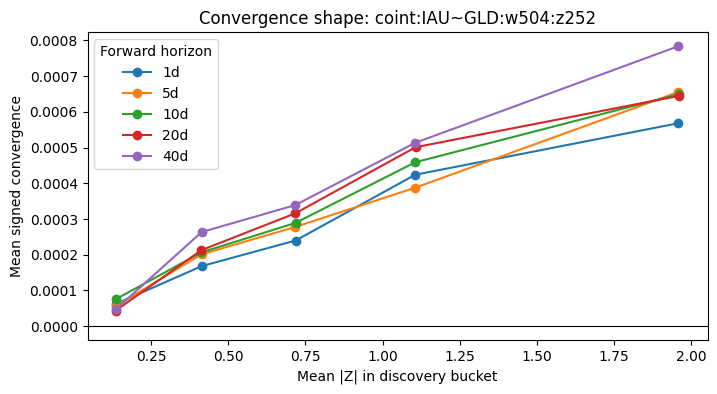

In [8]:
if not discovery_summary.empty:
    display(
        discovery_summary.sort_values(
            ["passes", "adjusted_pvalue", "mean_convergence"],
            ascending=[False, True, False],
        ).reset_index(drop=True)
    )
    rejection_table = (
        discovery_summary.groupby(["family", "rejection_reason"])
        .size()
        .rename("tests")
        .reset_index()
    )
    display(rejection_table)
    best_name_for_shape = str(
        discovery_summary.sort_values("adjusted_pvalue").iloc[0]["candidate"]
    )
    shape = convergence_buckets.loc[
        convergence_buckets["candidate"] == best_name_for_shape
    ]
    if not shape.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        for horizon, group in shape.groupby("horizon"):
            ax.plot(group["mean_abs_z"], group["mean_convergence"], marker="o", label=f"{horizon}d")
        ax.axhline(0.0, color="black", linewidth=0.8)
        ax.set(title=f"Convergence shape: {best_name_for_shape}", xlabel="Mean |Z| in discovery bucket", ylabel="Mean signed convergence")
        ax.legend(title="Forward horizon")
        plt.show()
else:
    rejection_table = pd.DataFrame()
    print("No candidate produced enough discovery evidence.")

## 9. Frozen strategy specification

The base entry, exit, holding period, sizing, timing, and cost assumptions are frozen before the untouched test is exposed.

In [9]:
primary_name = select_primary_candidate(discovery_summary)
candidate_by_name = {item.name: item for item in candidates}
primary_candidate = candidate_by_name.get(primary_name) if primary_name else None
if primary_name:
    primary_discovery = (
        discovery_summary.loc[
            (discovery_summary["candidate"] == primary_name)
            & discovery_summary["passes"]
        ]
        .sort_values(["adjusted_pvalue", "mean_convergence"], ascending=[True, False])
        .iloc[0]
    )
    frozen_horizon = int(primary_discovery["horizon"])
    print(f"Frozen primary candidate: {primary_name}")
    print(f"Frozen convergence horizon: {frozen_horizon} sessions")
    print("Frozen trading rule: enter |Z| crossing 2.0; exit |Z| <= 0.5, sign crossing, or day 20; one-session execution lag; 5 bps turnover and 2% annual short borrow.")
else:
    primary_discovery = None
    frozen_horizon = None
    print("No candidate passed every discovery gate; no rule is promoted.")

Frozen primary candidate: pca:GDX|GDX+GDXJ+SIL:w504:k10:z252
Frozen convergence horizon: 1 sessions
Frozen trading rule: enter |Z| crossing 2.0; exit |Z| <= 0.5, sign crossing, or day 20; one-session execution lag; 5 bps turnover and 2% annual short borrow.


## 10. Validation results and local robustness

Validation can reject the discovery candidate; robustness is diagnostic and never feeds parameter selection.

In [10]:
validation_evidence = None
validation_backtest = None
validation_robustness = None
validation_passed = False
if primary_candidate is not None:
    validation_evidence = split_evidence(
        primary_candidate, boundaries, "validation", frozen_horizon, CONFIG
    )
    validation_mask = pd.Series(
        (primary_candidate.zscore.index > boundaries.discovery_end)
        & (primary_candidate.zscore.index <= boundaries.validation_end),
        index=primary_candidate.zscore.index,
    )
    validation_positions = build_lagged_positions(
        primary_candidate, CONFIG, validation_mask
    )
    validation_backtest = run_backtest(
        validation_positions,
        simple_returns.reindex(primary_candidate.zscore.index),
        CONFIG,
    )
    validation_passed = passes_validation(validation_evidence, validation_backtest)
    validation_robustness = robustness_grid(
        primary_candidate, simple_returns, boundaries, "validation", CONFIG
    )
    display(validation_evidence.to_frame("validation"))
    display(pd.Series(validation_backtest.metrics, name="validation metrics").to_frame())
    print(f"Validation gate passed: {validation_passed}")
else:
    print("Validation not run because discovery promoted no candidate.")

,validation
split,validation
horizon,1
slope,0.0068
slope_pvalue,0.327144
bootstrap_pvalue,0.270365
event_count,89
mean_convergence,0.029027
ci_low,-0.047395
ci_high,0.13078


,validation metrics
trade_count,19.000000
average_holding_days,10.894737
median_holding_days,11.000000
annualized_return,-0.034649
annualized_volatility,0.040868
sharpe,-0.847838
sortino,-0.464237
maximum_drawdown,-0.137054
hit_rate,0.368421
average_trade_pnl,-0.007128


Validation gate passed: False


## 11. Untouched out-of-sample test

At most one validated primary candidate reaches this section.

In [11]:
test_evidence = None
test_backtest = None
test_robustness = None
if validation_passed:
    test_evidence = split_evidence(
        primary_candidate, boundaries, "test", frozen_horizon, CONFIG
    )
    test_mask = pd.Series(
        (primary_candidate.zscore.index > boundaries.validation_end)
        & (primary_candidate.zscore.index <= boundaries.test_end),
        index=primary_candidate.zscore.index,
    )
    test_positions = build_lagged_positions(primary_candidate, CONFIG, test_mask)
    test_backtest = run_backtest(
        test_positions,
        simple_returns.reindex(primary_candidate.zscore.index),
        CONFIG,
    )
    test_robustness = robustness_grid(
        primary_candidate, simple_returns, boundaries, "test", CONFIG
    )
    test_robustness["mean_convergence"] = float(test_evidence["mean_convergence"])
    display(test_evidence.to_frame("untouched test"))
    display(pd.Series(test_backtest.metrics, name="untouched test metrics").to_frame())
else:
    print("Untouched test not exposed because the primary strategy did not pass validation.")

if primary_candidate is None:
    verdict = "No useful statistical arbitrage"
elif not validation_passed:
    verdict = "Interesting but weak evidence"
else:
    verdict = classify_final_evidence(test_evidence, test_backtest, test_robustness)
print(f"Evidence verdict: {verdict}")

Untouched test not exposed because the primary strategy did not pass validation.
Evidence verdict: Interesting but weak evidence


## 12. Trading performance, regimes, and failure modes

Gross and net results, turnover, borrow, tails, drawdowns, subperiods, and lagged regimes are reported separately.

In [12]:
failure_modes = [
    "Current-survivor ETF universe creates survivorship bias.",
    "Daily adjusted closes cannot model intraday execution or auction slippage.",
    "Borrow costs are scenario assumptions rather than historical locate data.",
    "Yahoo histories can be revised and therefore require a recorded data cutoff.",
]
if not discovery_summary.empty:
    failure_modes.extend(
        sorted(set(discovery_summary.loc[~discovery_summary["passes"], "rejection_reason"]))
    )
if test_backtest is not None:
    regime_table = regime_performance(
        test_backtest.daily,
        simple_returns["SPY"].reindex(test_backtest.daily.index),
    )
    display(regime_table)
    display(test_robustness)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    (1.0 + test_backtest.daily["net_return"].fillna(0.0)).cumprod().plot(
        ax=axes[0], title="Untouched-test cumulative net wealth"
    )
    primary_candidate.leg_weights.plot(
        ax=axes[1], title="Lagged normalized hedge weights", alpha=0.8
    )
    axes[0].set_ylabel("Growth of 1.0")
    axes[1].set_ylabel("Portfolio weight")
    plt.tight_layout()
    plt.show()
elif validation_backtest is not None:
    display(pd.Series(validation_backtest.metrics, name="validation metrics").to_frame())
    display(validation_robustness)
else:
    print("No trading performance is reported because no candidate cleared discovery.")

,validation metrics
trade_count,19.000000
average_holding_days,10.894737
median_holding_days,11.000000
annualized_return,-0.034649
annualized_volatility,0.040868
sharpe,-0.847838
sortino,-0.464237
maximum_drawdown,-0.137054
hit_rate,0.368421
average_trade_pnl,-0.007128


,entry_z,exit_z,max_holding_days,transaction_cost_bps,annual_short_borrow,trade_count,average_holding_days,median_holding_days,annualized_return,annualized_volatility,...,average_trade_pnl,median_trade_pnl,worst_trade,trade_pnl_5pct,expected_shortfall_5pct,turnover,gross_return,transaction_cost,borrow_cost,net_return
0,1.5,0.0,10,2.0,0.00,36,7.805556,10.0,-0.022542,0.039033,...,-0.002448,9.615557e-04,-0.054499,-0.028586,-0.041657,72.184804,-0.073674,0.014437,0.000000,-0.088111
1,1.5,0.0,10,2.0,0.02,36,7.805556,10.0,-0.025377,0.039048,...,-0.002755,6.011246e-04,-0.054907,-0.028970,-0.042041,72.184804,-0.073674,0.014437,0.011079,-0.099190
2,1.5,0.0,10,2.0,0.05,36,7.805556,10.0,-0.029628,0.039074,...,-0.003217,6.047795e-05,-0.055519,-0.029544,-0.042617,72.184804,-0.073674,0.014437,0.027698,-0.115809
3,1.5,0.0,10,5.0,0.00,36,7.805556,10.0,-0.028082,0.039089,...,-0.003049,3.596656e-04,-0.055104,-0.029187,-0.042260,72.184804,-0.073674,0.036092,0.000000,-0.109767
4,1.5,0.0,10,5.0,0.02,36,7.805556,10.0,-0.030917,0.039105,...,-0.003357,-7.654747e-07,-0.055511,-0.029570,-0.042644,72.184804,-0.073674,0.036092,0.011079,-0.120846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,2.5,0.5,40,5.0,0.02,9,10.444444,11.0,-0.017359,0.037241,...,-0.007539,-8.024121e-03,-0.034886,-0.027967,-0.034886,18.159892,-0.055052,0.009080,0.003718,-0.067850
158,2.5,0.5,40,5.0,0.05,9,10.444444,11.0,-0.018785,0.037266,...,-0.008158,-8.668844e-03,-0.035563,-0.028719,-0.035563,18.159892,-0.055052,0.009080,0.009295,-0.073426
159,2.5,0.5,40,10.0,0.00,9,10.444444,11.0,-0.018730,0.037373,...,-0.008135,-8.595659e-03,-0.035477,-0.028493,-0.035477,18.159892,-0.055052,0.018160,0.000000,-0.073212
160,2.5,0.5,40,10.0,0.02,9,10.444444,11.0,-0.019681,0.037390,...,-0.008548,-9.025474e-03,-0.035929,-0.028995,-0.035929,18.159892,-0.055052,0.018160,0.003718,-0.076930


## 13. Concise final research summary

The executed notebook ends with the exact divergence, evidence, rule, out-of-sample result, robustness, limitations, and permitted verdict.

In [13]:
divergence_definition = (
    primary_candidate.diagnostics.get("definition")
    if primary_candidate is not None
    else None
)
reported_robustness = (
    test_robustness if test_robustness is not None else validation_robustness
)
final_summary = render_research_summary(
    primary_name,
    divergence_definition,
    primary_discovery,
    validation_evidence,
    test_evidence,
    test_backtest,
    reported_robustness,
    failure_modes,
    verdict,
)
display(Markdown("### Research conclusion\n\n" + final_summary.replace("\n", "\n\n")))
print(final_summary)

### Research conclusion

1. Best representation: pca:GDX|GDX+GDXJ+SIL:w504:k10:z252

2. Divergence definition: 10-day rolling-PCA reconstruction residual for GDX in GDX, GDXJ, SIL

3. Convergence evidence: discovery=horizon=1, slope=0.030561323439818384, event_count=94, adjusted_pvalue=0.02498750624687656; validation=horizon=1, slope=0.006800210195864883, event_count=89, bootstrap_pvalue=0.2703648175912044; test=Not available because no candidate reached this stage.

4. Trading rule: Enter when |Z| crosses 2.0, trade against the divergence with gross exposure 1.0, exit at |Z| <= 0.5, sign crossing, or 20 sessions; execute one close later; charge 5 bps one-way turnover and 2% annualized short borrow.

5. Untouched out-of-sample result: No untouched-test backtest was run because no strategy passed validation.

6. Robustness: 162 predeclared neighboring scenarios were evaluated; 0 had positive net return; net-return range [-0.1736, -0.0247].

7. Main failure modes: Current-survivor ETF universe creates survivorship bias.; Daily adjusted closes cannot model intraday execution or auction slippage.; Borrow costs are scenario assumptions rather than historical locate data.; Yahoo histories can be revised and therefore require a recorded data cutoff.; Holm-adjusted p-value is not below 0.05; fewer than 30 non-overlapping events; stationarity gate failed

8. Verdict: Interesting but weak evidence

1. Best representation: pca:GDX|GDX+GDXJ+SIL:w504:k10:z252
2. Divergence definition: 10-day rolling-PCA reconstruction residual for GDX in GDX, GDXJ, SIL
3. Convergence evidence: discovery=horizon=1, slope=0.030561323439818384, event_count=94, adjusted_pvalue=0.02498750624687656; validation=horizon=1, slope=0.006800210195864883, event_count=89, bootstrap_pvalue=0.2703648175912044; test=Not available because no candidate reached this stage.
4. Trading rule: Enter when |Z| crosses 2.0, trade against the divergence with gross exposure 1.0, exit at |Z| <= 0.5, sign crossing, or 20 sessions; execute one close later; charge 5 bps one-way turnover and 2% annualized short borrow.
5. Untouched out-of-sample result: No untouched-test backtest was run because no strategy passed validation.
6. Robustness: 162 predeclared neighboring scenarios were evaluated; 0 had positive net return; net-return range [-0.1736, -0.0247].
7. Main failure modes: Current-survivor ETF universe creates survivorship bia